In [3]:
1+1

2

In [3]:
from pathlib import Path

PROJECT_ROOT = Path(r'C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation')

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'figures'

SLEEP_EDF_DIR = RAW_DIR / 'sleep_edf' / 'sleep-cassette'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)
print(SLEEP_EDF_DIR)
print(PROCESSED_DIR)
print(FIGURES_DIR)
print(SLEEP_EDF_DIR.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\raw\sleep_edf\sleep-cassette
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures
True


In [4]:
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from scipy.signal import welch
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report
)

In [5]:
epoch_df = pd.read_csv(PROCESSED_DIR / 'sleep_edf_epoch_index.csv')

def get_subject_prefix(filename):
    m = re.match(r'^(SC\d{4})', filename)
    return m.group(1) if m else None

psg_files = {}

for f in sorted(SLEEP_EDF_DIR.glob('*-PSG.edf')):
    prefix = get_subject_prefix(f.name)
    if prefix is not None:
        psg_files[prefix] = f

print(epoch_df.shape)
print(sorted(epoch_df['subject_id'].unique()))
print(sorted(psg_files.keys()))
epoch_df.head()

(11129, 5)
['SC4001', 'SC4002', 'SC4011', 'SC4012']
['SC4001', 'SC4002', 'SC4011', 'SC4012']


,subject_id,epoch_start_sec,epoch_duration_sec,stage_label,original_description
0,SC4001,0.0,30,W,Sleep stage W
1,SC4001,30.0,30,W,Sleep stage W
2,SC4001,60.0,30,W,Sleep stage W
3,SC4001,90.0,30,W,Sleep stage W
4,SC4001,120.0,30,W,Sleep stage W


In [6]:
print(epoch_df['stage_label'].value_counts())
print()
print(epoch_df['subject_id'].value_counts())

stage_label
W      7562
N2     1845
N3      718
REM     686
N1      318
Name: count, dtype: int64

subject_id
SC4012    2848
SC4002    2829
SC4011    2802
SC4001    2650
Name: count, dtype: int64


In [7]:
def choose_channel(ch_names, preferred_patterns):
    for pattern in preferred_patterns:
        for ch in ch_names:
            if pattern.lower() in ch.lower():
                return ch
    return None


def bandpower(signal, sfreq, fmin, fmax):
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(len(signal), int(sfreq * 4)))
    mask = (freqs >= fmin) & (freqs < fmax)
    if mask.sum() == 0:
        return np.nan
    return np.trapezoid(psd[mask], freqs[mask])


def spectral_entropy(signal, sfreq):
    freqs, psd = welch(signal, fs=sfreq, nperseg=min(len(signal), int(sfreq * 4)))
    psd = np.maximum(psd, 1e-12)
    p = psd / psd.sum()
    return -(p * np.log(p)).sum()


def extract_epoch_signal_features(signal, sfreq):
    signal = np.asarray(signal, dtype=float)

    delta = bandpower(signal, sfreq, 0.5, 4)
    theta = bandpower(signal, sfreq, 4, 8)
    alpha = bandpower(signal, sfreq, 8, 12)
    sigma = bandpower(signal, sfreq, 12, 15)
    beta = bandpower(signal, sfreq, 15, 30)

    total = np.nansum([delta, theta, alpha, sigma, beta])

    return {
        'mean': np.mean(signal),
        'std': np.std(signal),
        'ptp': np.ptp(signal),
        'rms': np.sqrt(np.mean(signal ** 2)),
        'delta': delta,
        'theta': theta,
        'alpha': alpha,
        'sigma': sigma,
        'beta': beta,
        'delta_rel': delta / total if total > 0 else np.nan,
        'theta_rel': theta / total if total > 0 else np.nan,
        'alpha_rel': alpha / total if total > 0 else np.nan,
        'sigma_rel': sigma / total if total > 0 else np.nan,
        'beta_rel': beta / total if total > 0 else np.nan,
        'spectral_entropy': spectral_entropy(signal, sfreq),
    }

In [8]:
def extract_subject_epoch_features(subject_id, subject_epoch_df):
    if subject_id not in psg_files:
        raise FileNotFoundError(f'PSG file not found for {subject_id}')

    psg_path = psg_files[subject_id]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        raw = mne.io.read_raw_edf(psg_path, preload=False, verbose=False)

    sfreq = raw.info['sfreq']
    eeg_ch = choose_channel(raw.ch_names, ['EEG Fpz-Cz', 'EEG Pz-Oz', 'EEG'])

    print(f'Processing {subject_id} | EEG channel: {eeg_ch}')

    if eeg_ch is None:
        raise ValueError(f'No EEG channel found for {subject_id}')

    eeg_data = raw.get_data(picks=[eeg_ch])[0]

    feature_rows = []

    for row in subject_epoch_df.itertuples(index=False):
        start_sample = int(row.epoch_start_sec * sfreq)
        stop_sample = int((row.epoch_start_sec + row.epoch_duration_sec) * sfreq)

        signal = eeg_data[start_sample:stop_sample]
        feats = extract_epoch_signal_features(signal, sfreq)

        feats['subject_id'] = row.subject_id
        feats['epoch_start_sec'] = row.epoch_start_sec
        feats['epoch_duration_sec'] = row.epoch_duration_sec
        feats['stage_label'] = row.stage_label

        feature_rows.append(feats)

    return pd.DataFrame(feature_rows)

In [9]:
test_subject_id = epoch_df['subject_id'].iloc[0]
test_subject_epoch_df = epoch_df[epoch_df['subject_id'] == test_subject_id].copy()

print('test_subject_id =', test_subject_id)
print('n epochs =', len(test_subject_epoch_df))
print('starting feature extraction...')

test_features_df = extract_subject_epoch_features(test_subject_id, test_subject_epoch_df)

print('feature extraction done')
print(test_features_df.shape)
test_features_df.head()

test_subject_id = SC4001
n epochs = 2650
starting feature extraction...
Processing SC4001 | EEG channel: EEG Fpz-Cz
feature extraction done
(2650, 19)


,mean,std,ptp,rms,delta,theta,alpha,sigma,beta,delta_rel,theta_rel,alpha_rel,sigma_rel,beta_rel,spectral_entropy,subject_id,epoch_start_sec,epoch_duration_sec,stage_label
0,4.087560e-07,0.000036,0.000278,0.000036,6.711103e-10,9.333841e-11,8.105385e-12,2.386631e-12,8.697998e-12,0.856403,0.119109,0.010343,0.003046,0.011100,2.576818,SC4001,0.0,30,W
1,-5.228151e-07,0.000026,0.000206,0.000026,3.968841e-10,4.306789e-11,1.103013e-11,6.191904e-12,2.513861e-11,0.822877,0.089295,0.022869,0.012838,0.052121,3.182944,SC4001,30.0,30,W
2,9.948366e-07,0.000032,0.000217,0.000032,5.193779e-10,2.186782e-11,1.213675e-11,3.604512e-12,1.400208e-11,0.909611,0.038298,0.021256,0.006313,0.024522,2.461257,SC4001,60.0,30,W
3,-2.231795e-07,0.000018,0.000109,0.000018,1.869429e-10,1.858908e-11,1.271127e-11,1.635254e-12,6.137292e-12,0.827123,0.082247,0.056241,0.007235,0.027154,3.487448,SC4001,90.0,30,W
4,1.761055e-07,0.000017,0.000157,0.000017,1.821964e-10,3.528305e-11,1.110903e-11,1.380352e-12,5.427645e-12,0.773998,0.149888,0.047193,0.005864,0.023057,3.725143,SC4001,120.0,30,W


In [15]:
import time

subject_ids = sorted(epoch_df['subject_id'].unique())[:2]

print('Will process:', subject_ids, flush=True)

all_feature_dfs = []

for subject_id in subject_ids:
    t0 = time.time()
    print(f'\n=== START {subject_id} ===', flush=True)

    subject_epoch_df = (
        epoch_df[epoch_df['subject_id'] == subject_id]
        .sample(n=200, random_state=42)
        .sort_values('epoch_start_sec')
        .copy()
    )

    print(f'n epochs = {len(subject_epoch_df)}', flush=True)
    print(subject_epoch_df['stage_label'].value_counts(), flush=True)

    subject_features_df = extract_subject_epoch_features(subject_id, subject_epoch_df)

    print(f'{subject_id} done in {time.time() - t0:.1f} sec | shape = {subject_features_df.shape}', flush=True)
    all_feature_dfs.append(subject_features_df)

features_df = pd.concat(all_feature_dfs, ignore_index=True)

print('\nFINAL SHAPE:', features_df.shape, flush=True)
print('\nStage distribution in features_df:')
print(features_df['stage_label'].value_counts())
features_df.head()

Will process: ['SC4001', 'SC4002']

=== START SC4001 ===
n epochs = 200
stage_label
W      143
N3      27
N2      16
REM     11
N1       3
Name: count, dtype: int64
Processing SC4001 | EEG channel: EEG Fpz-Cz
SC4001 done in 2.4 sec | shape = (200, 19)

=== START SC4002 ===
n epochs = 200
stage_label
W      123
N2      30
N3      28
REM     15
N1       4
Name: count, dtype: int64
Processing SC4002 | EEG channel: EEG Fpz-Cz
SC4002 done in 3.3 sec | shape = (200, 19)

FINAL SHAPE: (400, 19)

Stage distribution in features_df:
stage_label
W      266
N3      55
N2      46
REM     26
N1       7
Name: count, dtype: int64


,mean,std,ptp,rms,delta,theta,alpha,sigma,beta,delta_rel,theta_rel,alpha_rel,sigma_rel,beta_rel,spectral_entropy,subject_id,epoch_start_sec,epoch_duration_sec,stage_label
0,1.762930e-07,0.000018,0.000164,0.000018,2.011866e-10,1.822409e-11,4.503480e-12,2.171126e-12,8.516518e-12,0.857566,0.077681,0.019196,0.009255,0.036302,3.212229,SC4001,960.0,30,W
1,5.458833e-07,0.000021,0.000201,0.000021,2.491789e-10,2.566523e-11,5.936703e-12,2.602521e-12,1.170772e-11,0.844414,0.086974,0.020118,0.008819,0.039675,3.158537,SC4001,1290.0,30,W
2,5.791101e-07,0.000018,0.000169,0.000018,1.417450e-10,1.043395e-11,3.625933e-12,1.197218e-12,5.886682e-12,0.870195,0.064056,0.022260,0.007350,0.036139,2.807399,SC4001,1320.0,30,W
3,1.751678e-07,0.000017,0.000155,0.000017,1.559042e-10,2.078096e-11,5.641164e-12,2.862331e-12,1.470008e-11,0.779955,0.103963,0.028222,0.014320,0.073541,3.581270,SC4001,1680.0,30,W
4,-1.925783e-07,0.000035,0.000248,0.000035,8.073924e-10,5.240452e-11,1.040764e-11,4.111670e-12,1.760415e-11,0.905229,0.058755,0.011669,0.004610,0.019737,2.843845,SC4001,2100.0,30,W


In [11]:
features_path = PROCESSED_DIR / 'sleep_edf_epoch_features.csv'
features_df.to_csv(features_path, index=False)

print(features_path)
print(features_path.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_edf_epoch_features.csv
True


In [16]:
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, cohen_kappa_score

feature_cols = [
    c for c in features_df.columns
    if c not in ['subject_id', 'epoch_start_sec', 'epoch_duration_sec', 'stage_label']
]

X = features_df[feature_cols].copy()
y = features_df['stage_label'].copy()
groups = features_df['subject_id'].copy()

print(X.shape)
print(y.shape)
print(sorted(groups.unique()))

(400, 15)
(400,)
['SC4001', 'SC4002']


In [17]:
logo = LeaveOneGroupOut()

rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced_subsample'
    ))
])

pred = cross_val_predict(rf_model, X, y, cv=logo, groups=groups)

print('done')

done


In [18]:
results_df = pd.DataFrame([{
    'model': 'RandomForest_mini',
    'macro_f1': f1_score(y, pred, average='macro'),
    'weighted_f1': f1_score(y, pred, average='weighted'),
    'balanced_accuracy': balanced_accuracy_score(y, pred),
    'cohen_kappa': cohen_kappa_score(y, pred)
}])

results_df

,model,macro_f1,weighted_f1,balanced_accuracy,cohen_kappa
0,RandomForest_mini,0.46377,0.697955,0.501472,0.456879


In [19]:
results_path = PROCESSED_DIR / 'sleep_staging_baseline_results.csv'
results_df.to_csv(results_path, index=False)

print(results_path)
print(results_path.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_staging_baseline_results.csv
True


In [20]:
print(classification_report(y, pred, labels=stage_order, zero_division=0))

NameError: name 'stage_order' is not defined

In [21]:
predictions_df = features_df[['subject_id', 'epoch_start_sec', 'stage_label']].copy()
predictions_df['predicted_stage'] = pred

preds_path = PROCESSED_DIR / 'sleep_staging_cv_predictions.csv'
predictions_df.to_csv(preds_path, index=False)

print(preds_path)
print(preds_path.exists())
predictions_df.head()

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_staging_cv_predictions.csv
True


,subject_id,epoch_start_sec,stage_label,predicted_stage
0,SC4001,960.0,W,REM
1,SC4001,1290.0,W,W
2,SC4001,1320.0,W,REM
3,SC4001,1680.0,W,W
4,SC4001,2100.0,W,N3


In [22]:
results_path = PROCESSED_DIR / 'sleep_staging_baseline_results_mini.csv'
results_df.to_csv(results_path, index=False)

predictions_df = features_df[['subject_id', 'epoch_start_sec', 'stage_label']].copy()
predictions_df['predicted_stage'] = pred

preds_path = PROCESSED_DIR / 'sleep_staging_cv_predictions_mini.csv'
predictions_df.to_csv(preds_path, index=False)

print(results_path, results_path.exists())
print(preds_path, preds_path.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_staging_baseline_results_mini.csv True
C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_staging_cv_predictions_mini.csv True


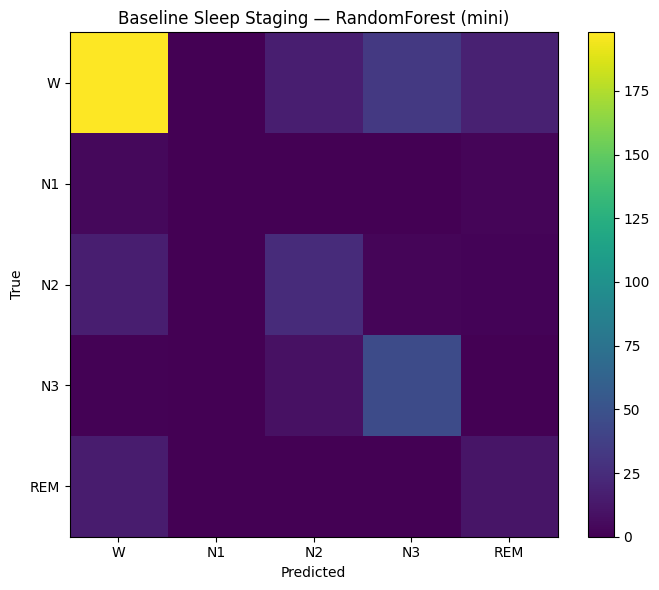

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\figures\baseline_confusion_matrix_mini.png True
              precision    recall  f1-score   support

           W       0.84      0.74      0.79       266
          N1       0.00      0.00      0.00         7
          N2       0.48      0.52      0.50        46
          N3       0.56      0.82      0.66        55
         REM       0.32      0.42      0.37        26

    accuracy                           0.69       400
   macro avg       0.44      0.50      0.46       400
weighted avg       0.71      0.69      0.70       400



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

stage_order = ['W', 'N1', 'N2', 'N3', 'REM']
cm = confusion_matrix(y, pred, labels=stage_order)

plt.figure(figsize=(7, 6))
plt.imshow(cm, aspect='auto')
plt.xticks(range(len(stage_order)), stage_order)
plt.yticks(range(len(stage_order)), stage_order)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Baseline Sleep Staging — RandomForest (mini)')
plt.colorbar()
plt.tight_layout()

fig_path = FIGURES_DIR / 'baseline_confusion_matrix_mini.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(fig_path, fig_path.exists())
print(classification_report(y, pred, labels=stage_order, zero_division=0))

In [24]:
report_dict = classification_report(y, pred, labels=stage_order, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report_dict).T
report_df

,precision,recall,f1-score,support
W,0.842553,0.744361,0.790419,266.000
N1,0.000000,0.000000,0.000000,7.000
N2,0.480000,0.521739,0.500000,46.000
N3,0.555556,0.818182,0.661765,55.000
REM,0.323529,0.423077,0.366667,26.000
accuracy,0.695000,0.695000,0.695000,0.695
macro avg,0.440328,0.501472,0.463770,400.000
weighted avg,0.712916,0.695000,0.697955,400.000


In [25]:
report_path = PROCESSED_DIR / 'sleep_staging_classification_report_mini.csv'
report_df.to_csv(report_path, index=True)

print(report_path)
print(report_path.exists())

C:\Users\vi\Sleep staging + fragmentation detection\sleep-staging-fragmentation\data\processed\sleep_staging_classification_report_mini.csv
True


## Baseline model interpretation

This mini-baseline sleep staging experiment shows that the pipeline is working and produces plausible stage-wise performance patterns.

The model performs best on Wake and N3, achieves moderate performance on N2, and struggles with REM and especially N1. This is expected for a small baseline model because N1 is both rare and difficult to separate from neighboring stages such as Wake and N2.

Overall, the results suggest that simple spectral EEG features already contain useful sleep-stage information, while performance on minority and transition-related stages remains limited.

## Conclusion

A baseline Random Forest model trained on epoch-level EEG spectral features was able to recover meaningful sleep-stage structure from Sleep-EDF mini-samples.

The strongest performance was observed for Wake and N3, while N1 remained the most difficult stage. This provides a reasonable baseline for the next stage of the project: deriving sleep fragmentation metrics from true and predicted stage sequences.

## Interpretation

This mini-baseline validates the core sleep staging pipeline on a small subset of Sleep-EDF data. The model shows plausible stage-wise behavior, with stronger performance on Wake and N3 and weaker performance on N1 and REM.

These results are best interpreted as a proof of pipeline functionality rather than a final benchmark.